# Data Analysis Workshop - Bonus Analysis

**Data source:**
<https://www.frontiersin.org/journals/microbiology/articles/10.3389/fmicb.2022.1050574/full>

This script performs the main statistical analyses for microbiome and
mycobiome data: <br>
- Principal Coordinates Analysis (PCoA) with Bray-Curtis <br>
- Procrustes analysis to compare microbiome and
mycobiome ordinations

## Library Installation

In [ ]:
# Please run the following code to install all necessary libraries, 
# unless you have already installed them using conda recipe: conda_recipes/r_libraries.yaml.

# R Library Installation Script
# Install required packages for microbiome analysis

# Install BiocManager if not already installed (needed for Bioconductor packages)
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

# Install Bioconductor packages
BiocManager::install("phyloseq")
BiocManager::install("GUniFrac")

# Install CRAN packages
install.packages("vegan")
install.packages("ape")
install.packages("ggplot2")
install.packages("ggpubr")
install.packages("PMA")
install.packages("reshape2")
install.packages("tidyr")
install.packages("phytools")
install.packages("compositions")

# Verify installations by loading libraries
cat("\n=== Verifying installations ===\n")
libraries <- c("phyloseq", "vegan", "ape", "ggplot2", "ggpubr", 
               "PMA", "parallel", "reshape2", "tidyr", "GUniFrac", "phytools", "compositions")

for (lib in libraries) {
  if (require(lib, character.only = TRUE, quietly = TRUE)) {
    cat(sprintf("✓ %s loaded successfully\n", lib))
  } else {
    cat(sprintf("✗ %s failed to load\n", lib))
  }
}

cat("\nInstallation complete!\n")

## Load Libraries

In [1]:
# Load necessary libraries for microbiome analysis
library(phyloseq)    # For microbiome data handling
library(vegan)       # For ecological diversity analysis
library(ape)         # For phylogenetic tree manipulation
library(ggplot2)     # For visualization
library(ggpubr)      # For publication-ready plots
library(PMA)         # For sparse CCA
library(parallel)    # For parallel computing
library(reshape2)    # For data reshaping
library(tidyr)       # For data tidying
library(GUniFrac)    # For UniFrac distance calculations
library(phytools)    # For phylogenetic tree tools
library(compositions) # For CLR transformation

Loading required package: permute

Loading required package: lattice

This is vegan 2.6-4


Attaching package: ‘ggpubr’


The following object is masked from ‘package:ape’:

    rotate



Attaching package: ‘tidyr’


The following object is masked from ‘package:reshape2’:

    smiths


Loading required package: maps


Attaching package: ‘phytools’


The following object is masked from ‘package:vegan’:

    scores


Welcome to compositions, a package for compositional data analysis.
Find an intro with "? compositions"



Attaching package: ‘compositions’


The following object is masked from ‘package:ape’:

    balance


The following objects are masked from ‘package:stats’:

    anova, cor, cov, dist, var


The following object is masked from ‘package:graphics’:

    segments


The following objects are masked from ‘package:base’:

    %*%, norm, scale, scale.default




### Custom ggplot theme

In [2]:
custom_theme <- theme_light() +
      theme(axis.text=element_text(size=20),
          axis.title=element_text(size=20), 
          plot.title=element_text(size=20, face="bold"),
          plot.subtitle=element_text(size=20, face="plain"),
          plot.caption = element_text(face = "italic"),
          text = element_text(size = 20), 
          legend.title=element_text(size=20),
          legend.text=element_text(size=20),
          axis.line = element_line(color = "darkgrey")) 

## Load Data

In [3]:
# Define path to preprocessed phyloseq objects
data_path <- '../../data/PRJNA880162/processed/phyloseq'

# Create output directory for analysis results
dir.create("../../data/data_analysis", showWarnings = FALSE)

In [4]:
# Load phyloseq objects containing microbiome (16S) and mycobiome (ITS) data
ps_microbiome <- readRDS('../../data/data_analysis/ps_microbiome.genus_agglomerated.rds')
ps_mycobiome <- readRDS('../../data/data_analysis/ps_mycobiome.genus_agglomerated.rds')

# Display summary of loaded objects
ps_microbiome
ps_mycobiome

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 632 taxa and 335 samples ]
sample_data() Sample Data:       [ 335 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 632 taxa by 7 taxonomic ranks ]
phy_tree()    Phylogenetic Tree: [ 632 tips and 631 internal nodes ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 140 taxa and 335 samples ]
sample_data() Sample Data:       [ 335 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 140 taxa by 7 taxonomic ranks ]
phy_tree()    Phylogenetic Tree: [ 140 tips and 139 internal nodes ]

In [5]:
# Preview OTU table structure
otu_table_preview <- data.frame(head(otu_table(ps_microbiome)))

# Preview taxonomy table structure
tax_table_preview <- data.frame(head(tax_table(ps_microbiome)))

# PCoA based on Bray-Curtis Distance

Principal Coordinates Analysis (PCoA) is an ordination method that
visualizes the similarity/dissimilarity between samples in a reduced
dimensional space.

In [6]:
# Extract OTU table and calculate Bray-Curtis dissimilarity
otu_data_microbiome <- data.frame(otu_table(ps_microbiome))
bray_curtis_dist_microbiome <- vegdist(otu_data_microbiome, method = "bray")

# Perform PCoA
pcoa_res_microbiome <- pcoa(bray_curtis_dist_microbiome)

# Extract first two principal coordinates for plotting
pcoa_coordinates_microbiome <- data.frame(pcoa_res_microbiome$vectors)[, c('Axis.1', 'Axis.2')]
colnames(pcoa_coordinates_microbiome) <- c('PCoA1', 'PCoA2')
pcoa_coordinates_microbiome <- cbind(pcoa_coordinates_microbiome, sample_data(ps_microbiome))
pcoa_coordinates_microbiome$sample_type <- 'Microbiome'

In [7]:
# Repeat for mycobiome
otu_data_mycobiome <- data.frame(otu_table(ps_mycobiome))
bray_curtis_dist_mycobiome <- vegdist(otu_data_mycobiome, method = "bray")
pcoa_res_mycobiome <- pcoa(bray_curtis_dist_mycobiome)

pcoa_coordinates_mycobiome <- data.frame(pcoa_res_mycobiome$vectors)[, c('Axis.1', 'Axis.2')]
colnames(pcoa_coordinates_mycobiome) <- c('PCoA1', 'PCoA2')
pcoa_coordinates_mycobiome <- cbind(pcoa_coordinates_mycobiome, sample_data(ps_mycobiome))
pcoa_coordinates_mycobiome$sample_type <- 'Mycobiome'

## Basic PCoA Plots

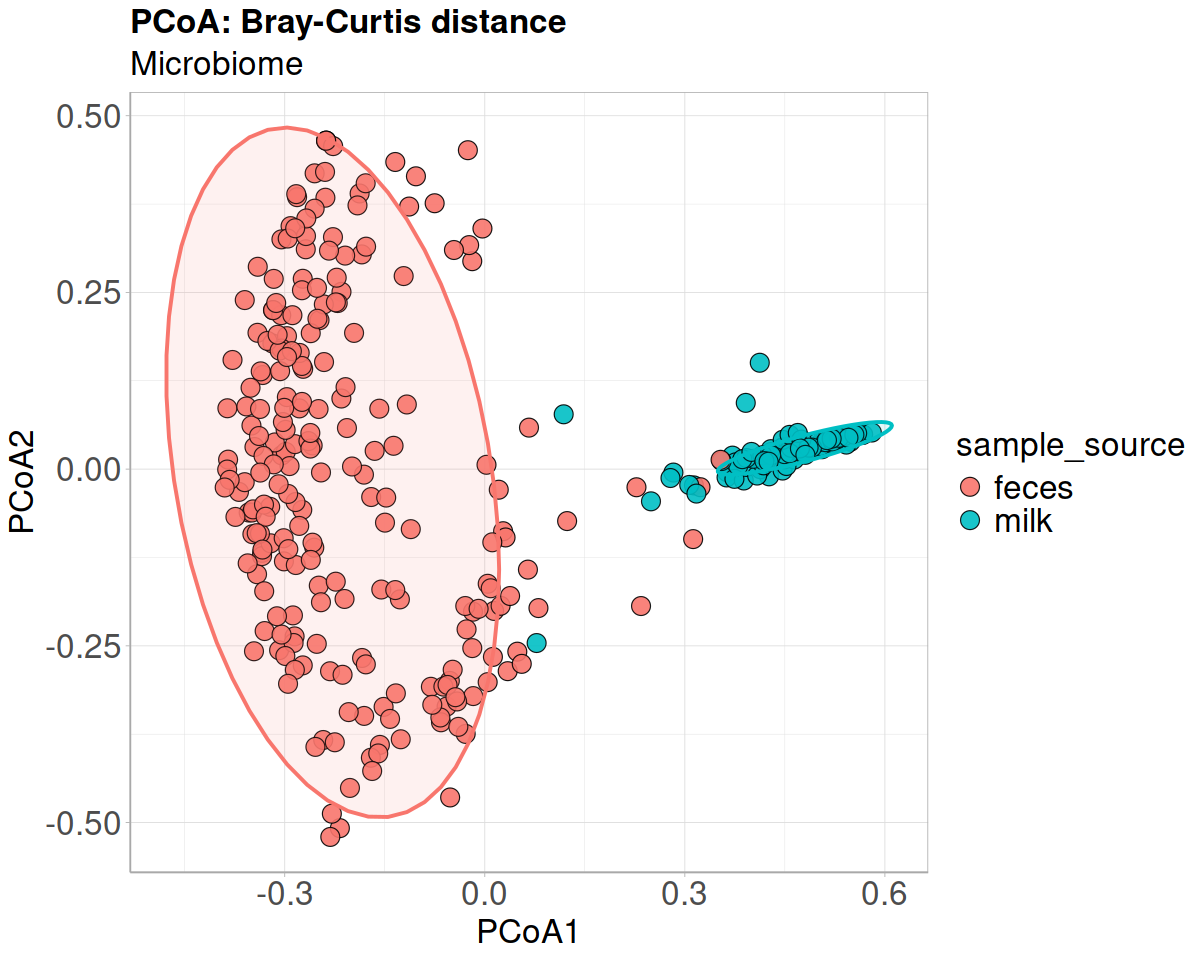

In [8]:
# Set plot dimensions
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

# Create PCoA plot for microbiome
pcoa_braycurtis_microbiome <- ggplot(data = pcoa_coordinates_microbiome, aes(x=PCoA1, y=PCoA2)) +
    # Plot sample points
    geom_point(aes(fill = sample_source), 
               size = 5, alpha=0.9, pch=21) +
    # Add confidence ellipses for each group
    stat_ellipse(geom = "polygon",
                 aes(color = sample_source, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
    # Add titles
    labs(title = "PCoA: Bray-Curtis distance", 
         subtitle = "Microbiome") +
    # Customize theme
    custom_theme

pcoa_braycurtis_microbiome

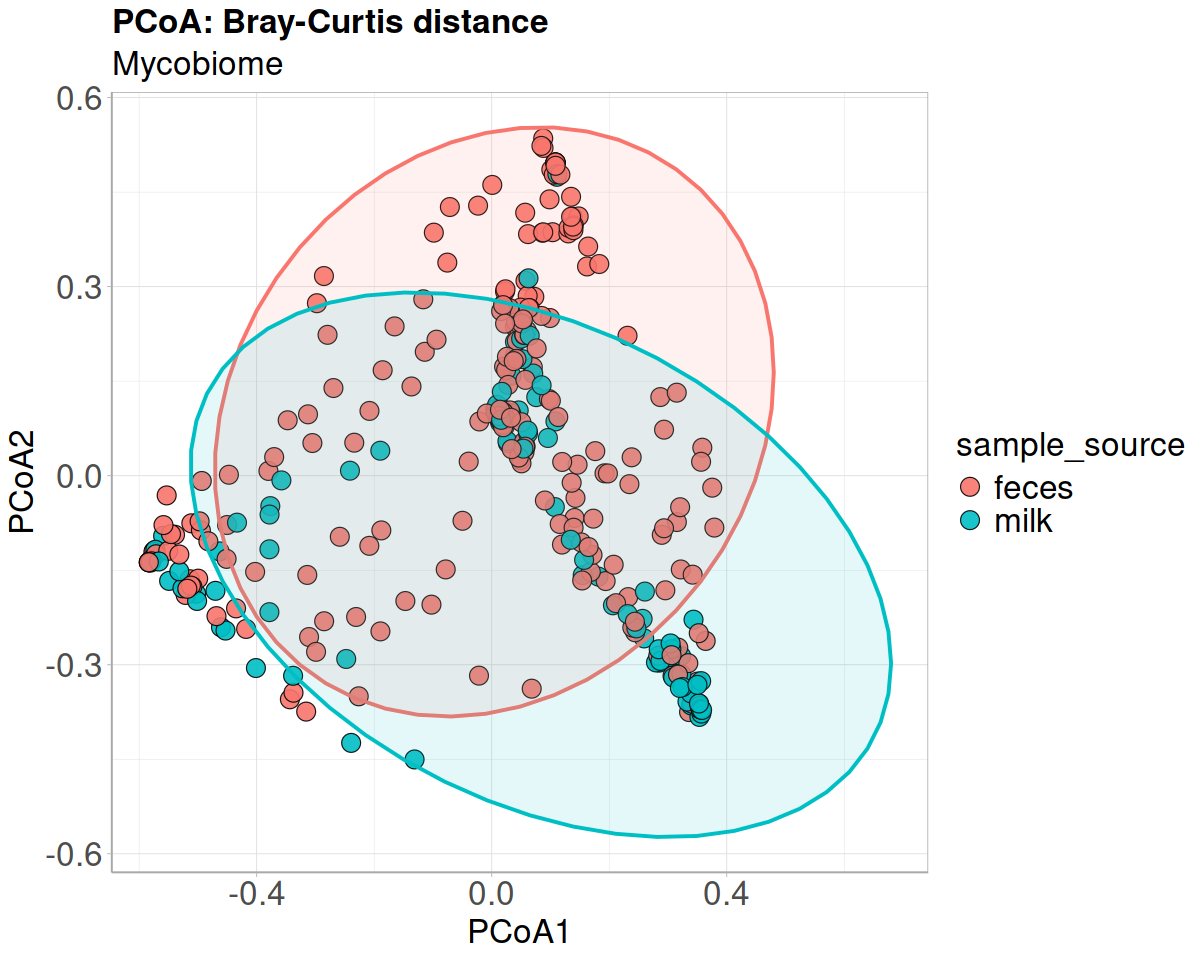

In [9]:
# Create PCoA plot for mycobiome
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_braycurtis_mycobiome <- ggplot(data = pcoa_coordinates_mycobiome, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill = sample_source), 
               size = 5, alpha=0.9, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_source, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
    labs(title = "PCoA: Bray-Curtis distance", 
         subtitle = "Mycobiome") +
    custom_theme 

pcoa_braycurtis_mycobiome

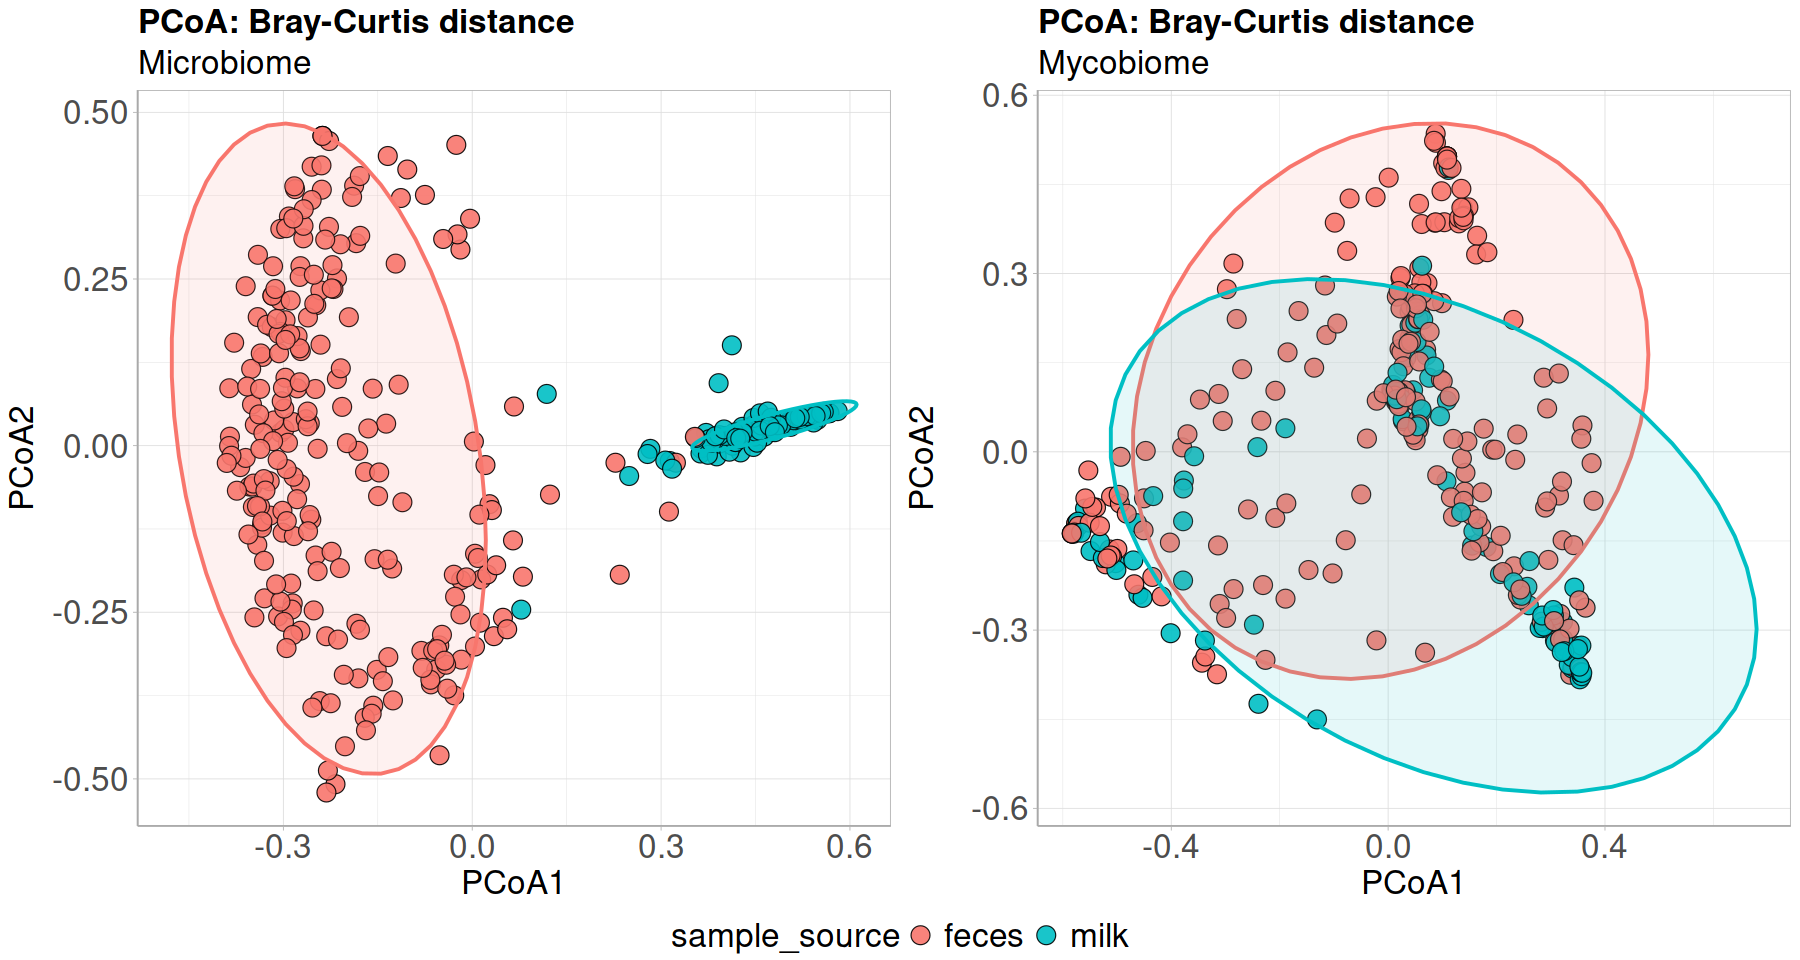

In [10]:
# Combine both plots side by side
width = 15
height = 8
options(repr.plot.width=width, repr.plot.height=height)

p <- ggarrange(pcoa_braycurtis_microbiome, pcoa_braycurtis_mycobiome,
          ncol = 2, nrow = 1, align = "hv", 
          common.legend = TRUE, legend = "bottom") 
print(p)

## PCoA Add-ons

### Loadings

Loadings show which taxa contribute most to the separation along each
axis.

In [11]:
# Function to compute loadings (correlation of taxa with PCoA axes)
# Credit source: https://github.com/cran/ape/blob/master/R/biplot.pcoa.R
compute_loadings <- function(x, Y) {
    plot.axes <- c(1, 2)
    pr.coo <- x$vectors
    n <- nrow(Y)
    points.stand <- scale(pr.coo[, plot.axes])
    S <- cov(Y, points.stand)
    U <- S %*% diag((x$values$Eigenvalues[plot.axes]/(n-1))^(-0.5))
    colnames(U) <- c('PCoA1', 'PCoA2')
    U <- data.frame(U)
    U['Length'] <- sqrt(U[['PCoA1']]^2 + U[['PCoA2']]^2)
    U <- U[order(-U[['Length']]), ]
    # Determine which quadrant each loading is in
    U['direction'] <- (U['PCoA1']/abs(U['PCoA1'])+1)/2 + (U['PCoA2']/abs(U['PCoA2'])+3)
    return(U)
}

In [12]:
# Compute loadings for microbiome
loadings_microbiome <- compute_loadings(pcoa_res_microbiome, otu_table(ps_microbiome))

# Select top 5 taxa with largest loadings
loadings_microbiome_selected <- loadings_microbiome[1:5, ]
loadings_microbiome_selected['names'] <- rownames(loadings_microbiome_selected)

# Select one representative loading per quadrant for clarity
loadings_microbiome_selected <- loadings_microbiome_selected[
    row.names(unique(loadings_microbiome_selected['direction'])), ]

In [13]:
# Compute loadings for mycobiome
loadings_mycobiome <- compute_loadings(pcoa_res_mycobiome, otu_table(ps_mycobiome))

loadings_mycobiome_selected <- loadings_mycobiome[1:5, ]
loadings_mycobiome_selected['names'] <- rownames(loadings_mycobiome_selected)
loadings_mycobiome_selected <- loadings_mycobiome_selected[
    row.names(unique(loadings_mycobiome_selected['direction'])), ]

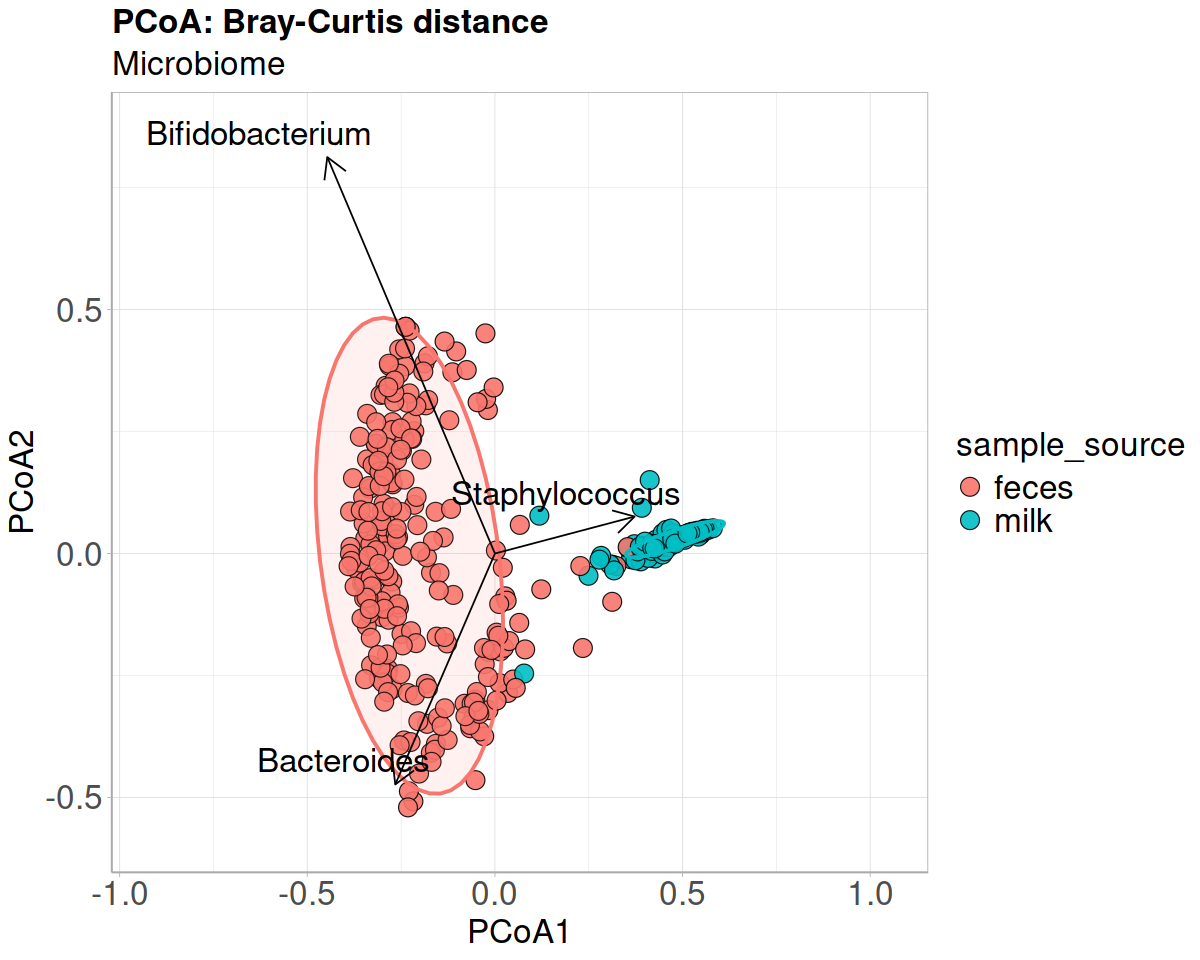

In [14]:
# Create enhanced PCoA plot with loadings for microbiome
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_braycurtis_microbiome <- ggplot(data = pcoa_coordinates_microbiome, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill = sample_source), 
               size = 5, alpha=0.9, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_source, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
################################### ADD-ON #####################################
# plot projected microbial genera
      geom_segment(data = loadings_microbiome_selected, 
                   aes(x = 0, y = 0, xend = PCoA1, yend = PCoA2), 
                   arrow = arrow(length = unit(0.03, "npc")), alpha = 1) + 
# plot names of the projected genera
      geom_text(data = loadings_microbiome_selected, 
                mapping = aes(x = PCoA1, y = PCoA2, label = names), 
                hjust = 0.8, vjust = -0.5, colour = "black", size = 7) +
# expand x and y limits to make plot better looking
      scale_x_continuous(expand = expansion(mult = 0.5)) +
      scale_y_continuous(expand = expansion(mult = 0.1)) +
################################################################################
    labs(title = "PCoA: Bray-Curtis distance", 
         subtitle = "Microbiome") +
    custom_theme 

pcoa_braycurtis_microbiome

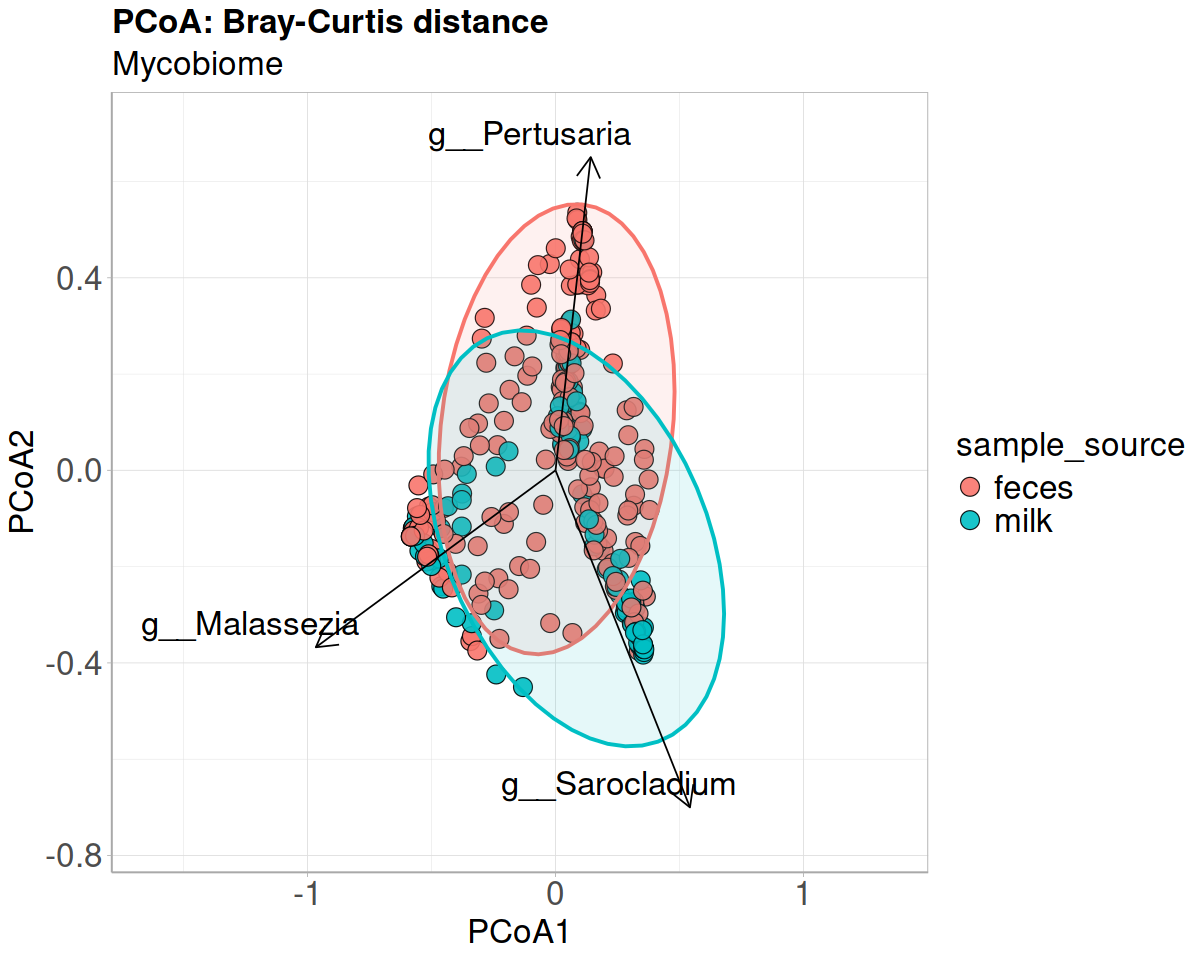

In [15]:
# Create enhanced PCoA plot with loadings for mycobiome
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_braycurtis_mycobiome <- ggplot(data = pcoa_coordinates_mycobiome, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill = sample_source), 
               size = 5, alpha=0.9, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_source, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
  ################################### ADD-ON #####################################
# plot projected mycobial genera
      geom_segment(data = loadings_mycobiome_selected, 
                   aes(x = 0, y = 0, xend = PCoA1, yend = PCoA2), 
                   arrow = arrow(length = unit(0.03, "npc")), alpha = 1) + 
# plot names of the projected genera
      geom_text(data = loadings_mycobiome_selected, 
                mapping = aes(x = PCoA1, y = PCoA2, label = names), 
                hjust = 0.8, vjust = -0.5, colour = "black", size = 7) +
# expand x and y limits to make plot better looking
      scale_x_continuous(expand = expansion(mult = 0.5)) +
      scale_y_continuous(expand = expansion(mult = 0.1)) +
################################################################################
    labs(title = "PCoA: Bray-Curtis distance", 
         subtitle = "Mycobiome") +
    custom_theme

pcoa_braycurtis_mycobiome

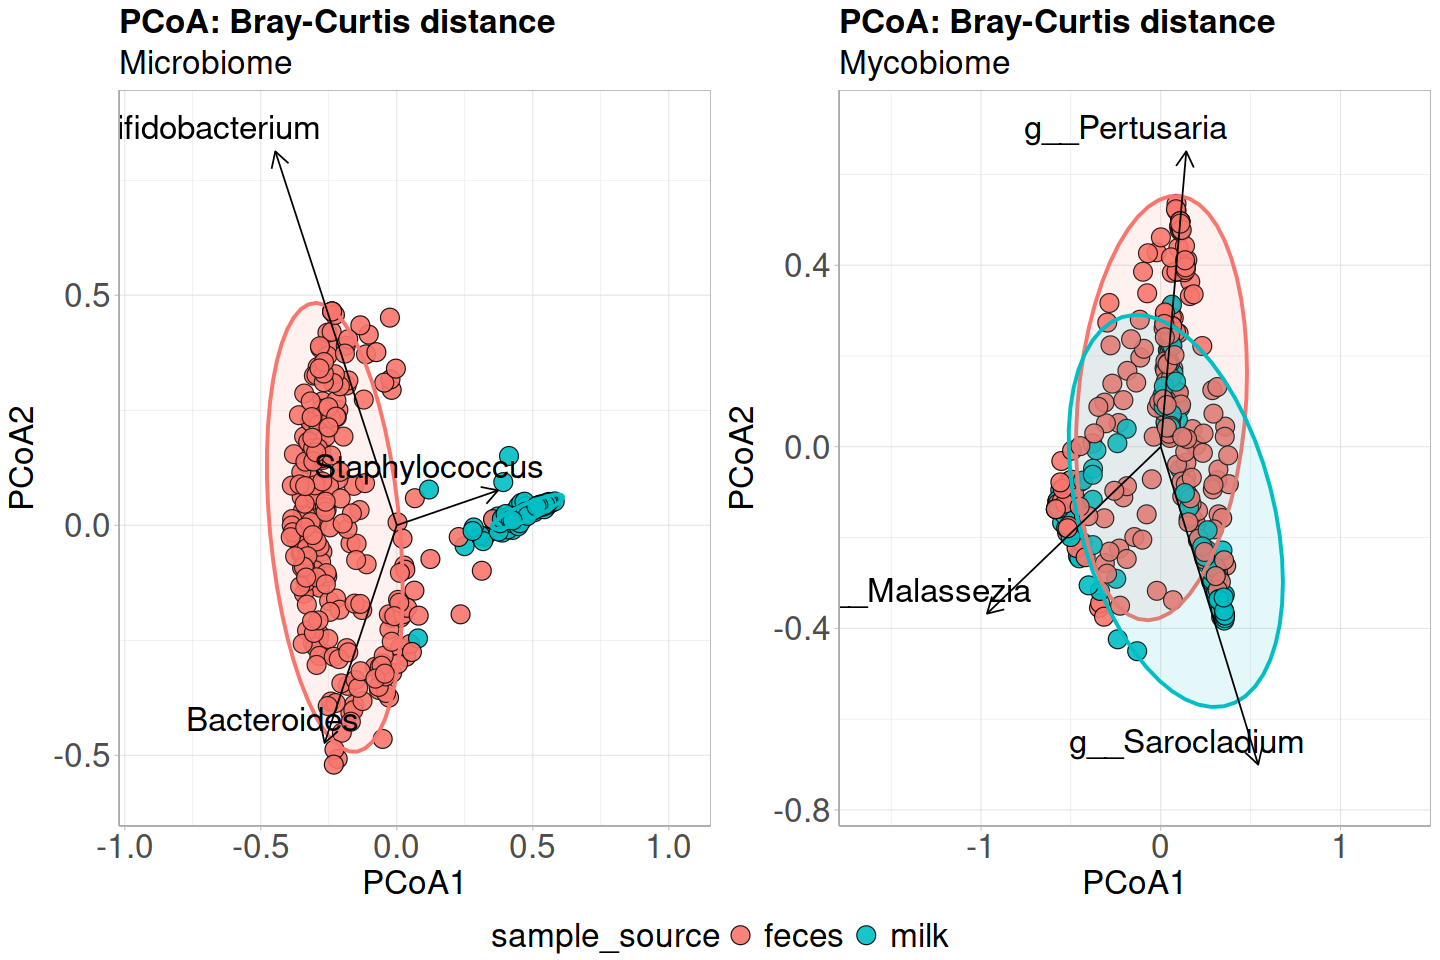

In [16]:
# Combine both enhanced plots
width = 12
height = 8
options(repr.plot.width=width, repr.plot.height=height)

p <- ggarrange(pcoa_braycurtis_microbiome, pcoa_braycurtis_mycobiome,
          ncol = 2, nrow = 1, align = "hv", 
          common.legend = TRUE, legend = "bottom") 
print(p)

### Statistical Testing with PERMANOVA

PERMANOVA tests whether group centroids differ significantly in
multivariate space.

In [17]:
# PERMANOVA test for microbiome
# Tests if sample source significantly affects community composition
set.seed(123)  # Set seed for reproducibility
permanova_microbiome <- adonis2(
    as.formula(paste0("bray_curtis_dist_microbiome ~ sample_source")), 
    data=data.frame(sample_data(ps_microbiome)), 
    permutations=9999)
permanova_microbiome

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample_source,1,31.78479,0.2984978,141.6956,1e-04
Residual,333,74.69769,0.7015022,NA,NA
Total,334,106.48248,1.0000000,NA,NA


In [18]:
# PERMANOVA test for mycobiome
set.seed(234)
permanova_mycobiome <- adonis2(
    as.formula(paste0("bray_curtis_dist_mycobiome ~ sample_source")), 
    data=data.frame(sample_data(ps_mycobiome)), 
    permutations=9999)
permanova_mycobiome

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample_source,1,3.767247,0.02902908,9.955688,1e-04
Residual,333,126.007676,0.97097092,NA,NA
Total,334,129.774922,1.00000000,NA,NA


### Explained Variance

In [19]:
# Calculate percentage of variance explained by each axis
explained_variance_microbiome <- pcoa_res_microbiome$values$Relative_eig * 100
explained_variance_mycobiome <- pcoa_res_mycobiome$values$Relative_eig * 100

### Updated Plots with Statistics

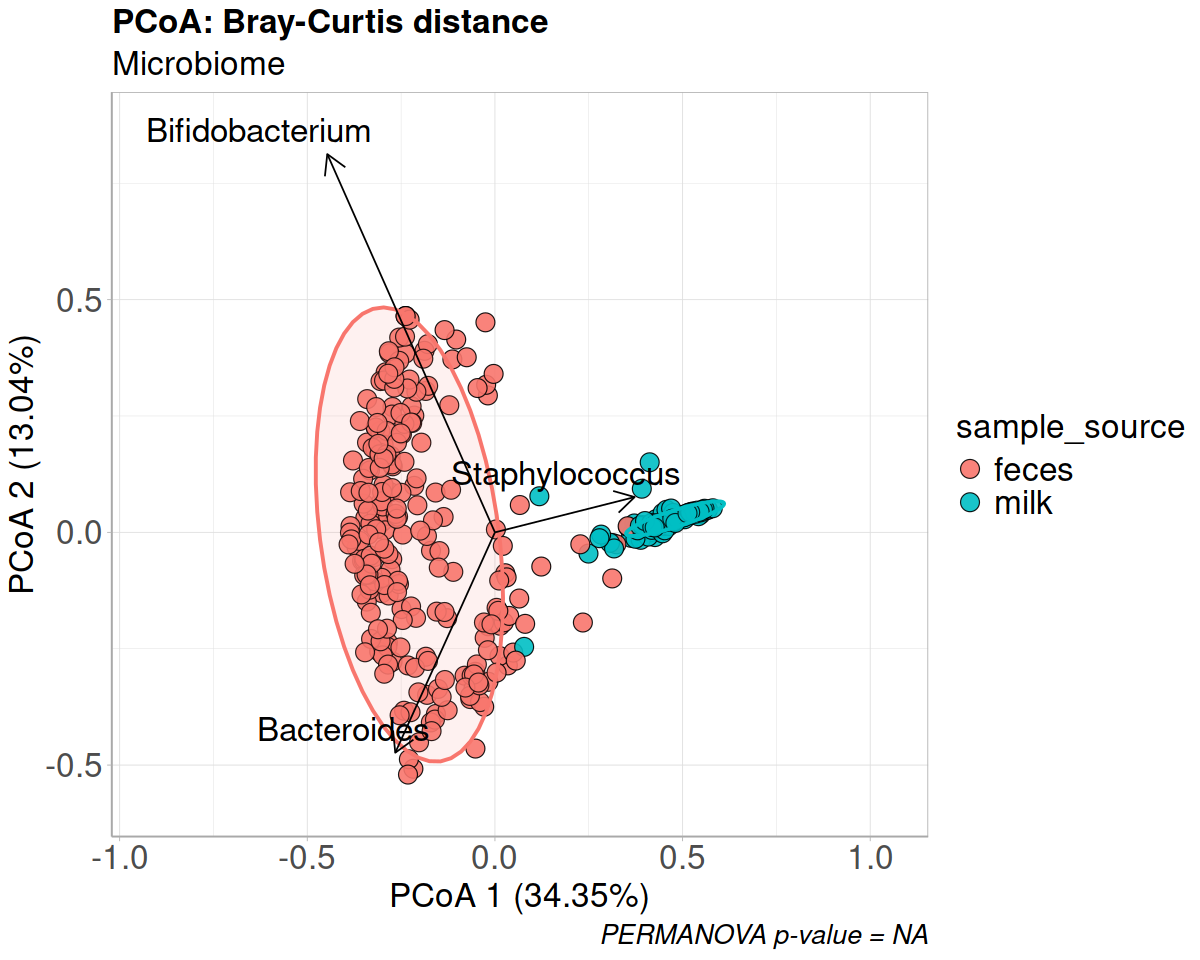

In [20]:
# Create final publication-ready plots with all annotations
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_braycurtis_microbiome <- ggplot(data = pcoa_coordinates_microbiome, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill = sample_source), 
               size = 5, alpha=0.9, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_source, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
    geom_segment(data = loadings_microbiome_selected, 
                 aes(x = 0, y = 0, xend = PCoA1, yend = PCoA2), 
                 arrow = arrow(length = unit(0.03, "npc")), alpha = 1) + 
    geom_text(data = loadings_microbiome_selected, 
              mapping = aes(x = PCoA1, y = PCoA2, label = names), 
              hjust = 0.8, vjust = -0.5, colour = "black", size = 7) +
    scale_x_continuous(expand = expansion(mult = 0.5)) +
    scale_y_continuous(expand = expansion(mult = 0.1)) +
  ################################### ADD-ON #####################################
    # Add axis labels with explained variance
    labs(x = paste0("PCoA 1 (", sprintf('%.2f', explained_variance_microbiome[1]), "%)"), 
         y = paste0("PCoA 2 (", sprintf('%.2f', explained_variance_microbiome[2]), "%)"), 
         title = "PCoA: Bray-Curtis distance", 
         subtitle = "Microbiome",
         caption = paste0("PERMANOVA p-value = ", permanova_microbiome['Model', 'Pr(>F)'])) +
  ################################################################################
    custom_theme

pcoa_braycurtis_microbiome

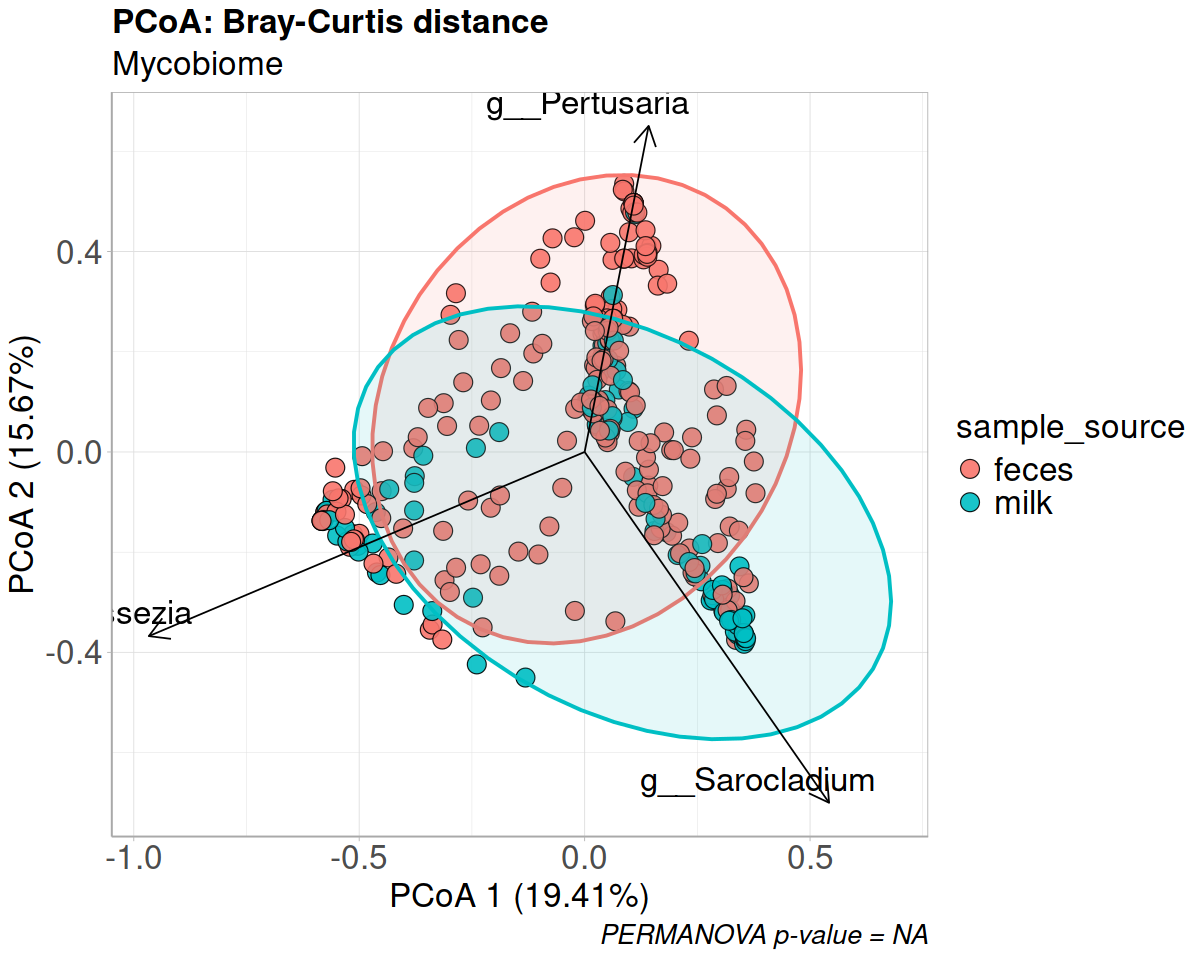

In [21]:
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_braycurtis_mycobiome <- ggplot(data = pcoa_coordinates_mycobiome, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill = sample_source), 
               size = 5, alpha=0.9, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_source, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
  # plot projected microbial genera
      geom_segment(data = loadings_mycobiome_selected, 
                   aes(x = 0, y = 0, xend = PCoA1, yend = PCoA2), 
                   arrow = arrow(length = unit(0.03, "npc")), alpha = 1) + 
# plot names of the projected genera
      geom_text(data = loadings_mycobiome_selected, 
                mapping = aes(x = PCoA1, y = PCoA2, label = names), 
                hjust = 0.8, vjust = -0.5, colour = "black", size = 7) +
################################### ADD-ON #####################################
# add titles
      labs(x = paste0("PCoA 1 (", sprintf('%.2f', explained_variance_mycobiome[1]), "%)"), 
           y = paste0("PCoA 2 (", sprintf('%.2f', explained_variance_mycobiome[2]), "%)"), 
           title = "PCoA: Bray-Curtis distance", 
           subtitle = "Mycobiome",
           caption = paste0("PERMANOVA p-value = ", permanova_mycobiome['Model', 'Pr(>F)']))+
################################################################################
    custom_theme 

pcoa_braycurtis_mycobiome

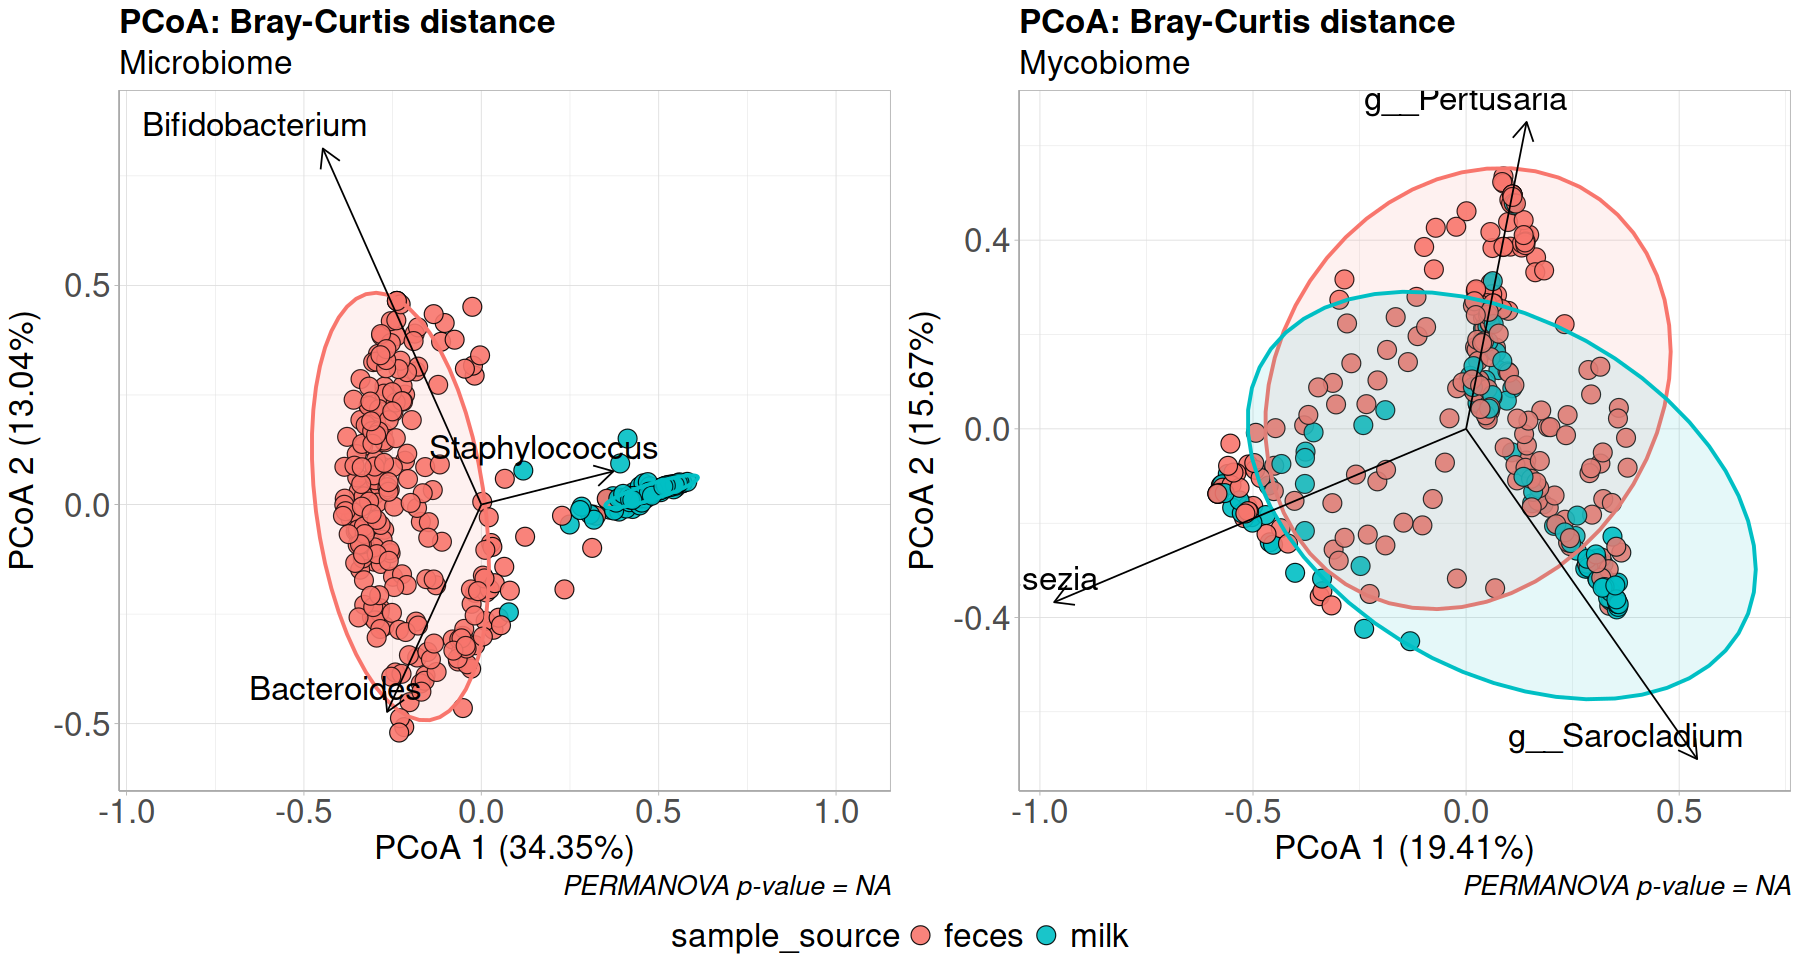

In [22]:
# Combine final plots
width = 15
height = 8
options(repr.plot.width=width, repr.plot.height=height)

p <- ggarrange(pcoa_braycurtis_microbiome, pcoa_braycurtis_mycobiome,
          ncol = 2, nrow = 1, align = "hv", 
          common.legend = TRUE, legend = "bottom") 
print(p)

# Procrustes Analysis for PCoA Bray-Curtis

**About Procrustes Analysis:** "Procrustes analysis is named after a
bandit from ancient Greek mythology that would hunt people down, and
adjust their sizes to his iron bed by either cutting their limbs off or
stretching them."

**Citation source:**
[https://medium.com/\@olga_kravchenko/generalized-procrustes-analysis-with-python-numpy-c571e8e8a421](https://medium.com/@olga_kravchenko/generalized-procrustes-analysis-with-python-numpy-c571e8e8a421){.uri}

**Figure source:**
<https://www.scielo.br/j/brag/a/w4DBp6nzxwvPFDR7JYWGWDr/?lang=en>

Procrustes analysis tests whether two ordinations have similar
structures by rotating, translating, and scaling one to match the other.

![Procrustes](https://minio.scielo.br/documentstore/1678-4499/w4DBp6nzxwvPFDR7JYWGWDr/fe4b2ee3c20d0671acaeb9176a3a4705df41e0d7.jpg)

In [30]:
# Combine coordinates
pcoa_coordinates <- rbind(pcoa_coordinates_microbiome,
                          pcoa_coordinates_mycobiome)

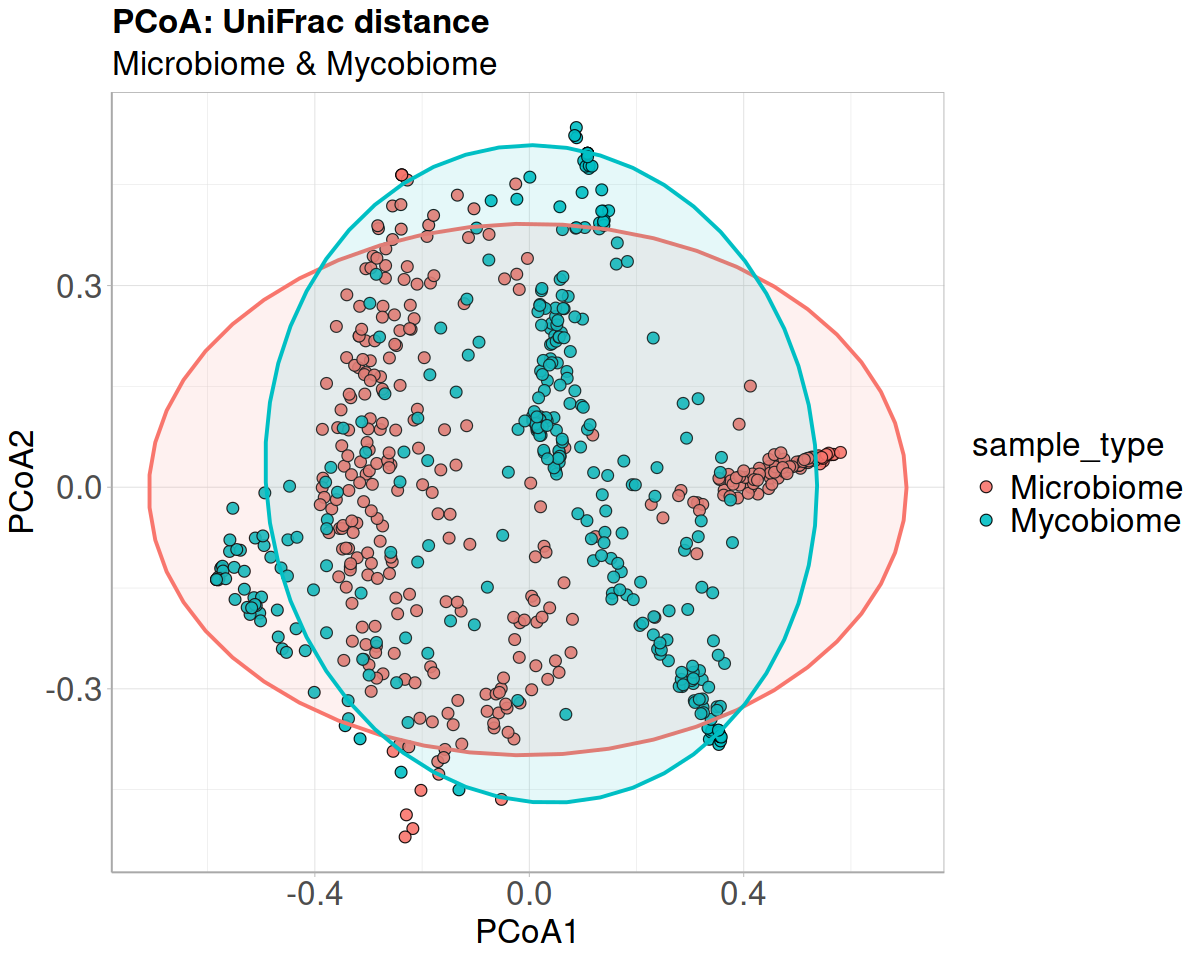

In [31]:
# Plot before Procrustes
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_plot <- ggplot(data = pcoa_coordinates, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill=sample_type), 
               size = 3, alpha=0.9, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_type, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
    labs(title = "PCoA: UniFrac distance", 
         subtitle = "Microbiome & Mycobiome") +
    custom_theme

pcoa_plot

In [32]:
n <- min(ncol(pcoa_res_microbiome$vectors), ncol(pcoa_res_mycobiome$vectors))
# n <- 2

procrustes_res <- procrustes(data.frame(pcoa_res_microbiome$vectors[, 1:n]), 
                             data.frame(pcoa_res_mycobiome$vectors[, 1:n]), 
                            scale=FALSE)
pcoa_rotated_mycobiome <- data.frame(procrustes_res$Yrot)
colnames(pcoa_rotated_mycobiome) <- paste0('PCoA', c(1:n))
pcoa_original_microbiome <- data.frame(procrustes_res$X)
colnames(pcoa_original_microbiome) <- paste0('PCoA', c(1:n))
pcoa_original_microbiome$sample_type <- 'Microbiome'
pcoa_rotated_mycobiome$sample_type <- 'Mycobiome'
pcoa_coordinates_procrustes <- rbind(pcoa_original_microbiome, pcoa_rotated_mycobiome)

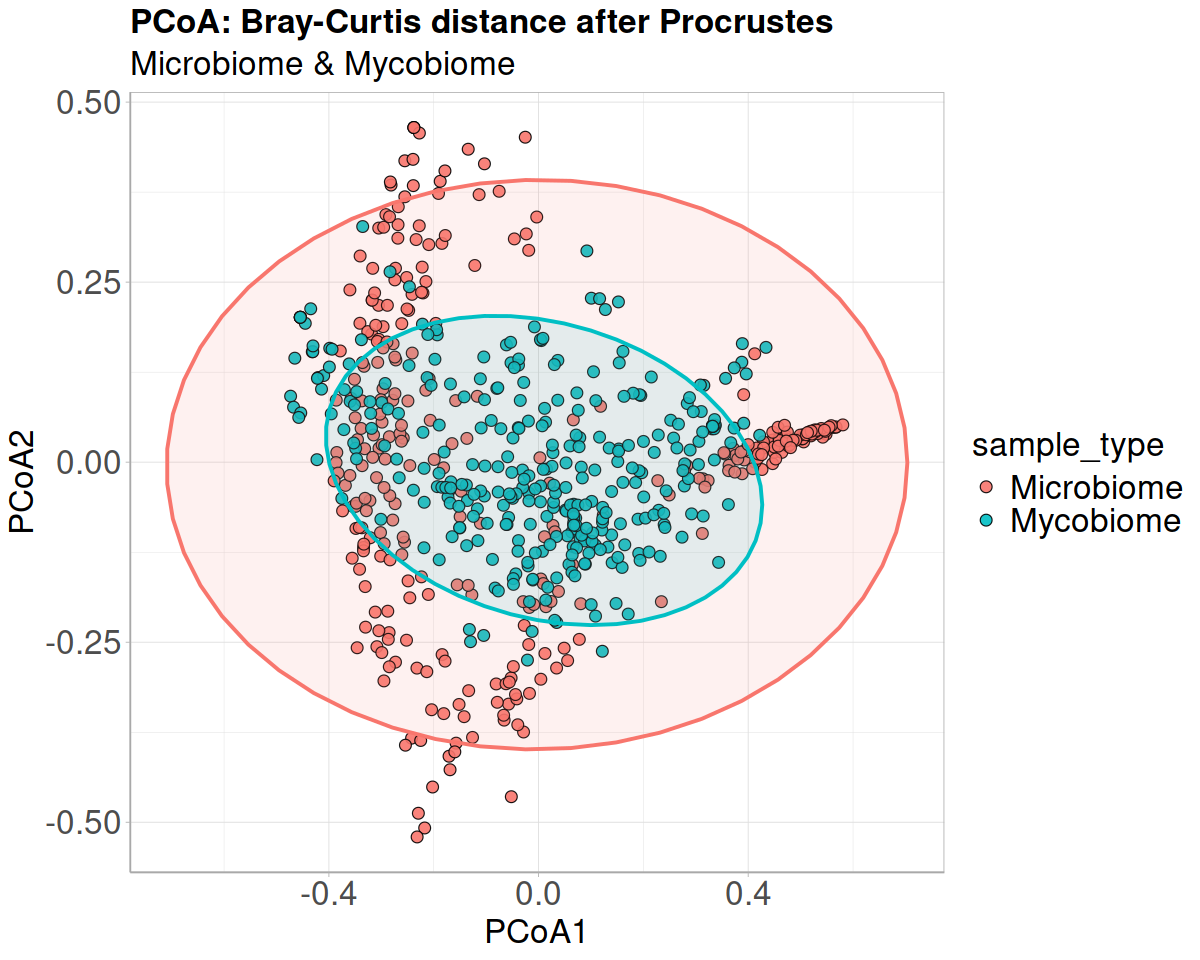

In [33]:
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_plot <- ggplot(data = pcoa_coordinates_procrustes, aes(x=PCoA1, y=PCoA2)) +
# plot sample values projected on PCoA
      geom_point(aes(fill=sample_type), 
                 size = 3, alpha=0.9, pch=21) +
# plot group circles
      stat_ellipse(geom = "polygon",
                   aes(color = sample_type, 
                       fill = after_scale(alpha(colour, 0.1))), lwd=1.1, level=0.9, show.legend = FALSE) +
# add titles
      labs(
           title = "PCoA: Bray-Curtis distance after Procrustes", 
           subtitle = "Microbiome & Mycobiome") +
# custom plot design
     custom_theme
pcoa_plot

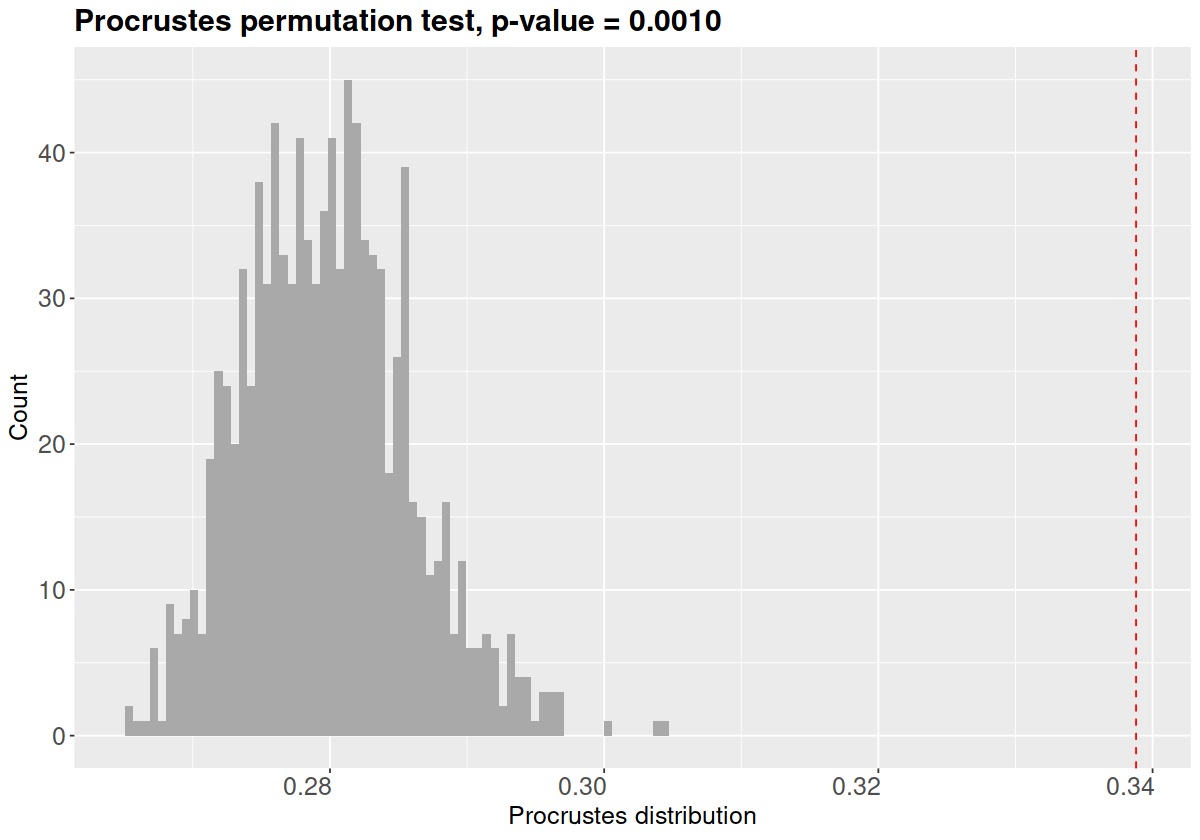

In [34]:
# Perform Procrustes permutation test
width = 10
height = 7
options(repr.plot.width=width, repr.plot.height=height)

n <- min(ncol(pcoa_res_microbiome$vectors), ncol(pcoa_res_mycobiome$vectors))

set.seed(123)
procrustes_permutation <- protest(data.frame(pcoa_res_microbiome$vectors[, 1:n]), 
                                  data.frame(pcoa_res_mycobiome$vectors[, 1:n]), 
                                  scale=FALSE, permutations = 999)

procrustes_permutation_d <- data.frame(distances = procrustes_permutation$t)
procrustes_permutation_d0 <- procrustes_permutation$t0

procrustes_dist_plot <- ggplot(data = procrustes_permutation_d, aes(x = distances)) +
    geom_histogram(bins = 125, fill = "dark grey") +
    geom_vline(xintercept = procrustes_permutation_d0, lty = 2, color = "red") +
    labs(x = "Procrustes distribution", y = "Count") +
    theme(axis.text.x = element_text(hjust = 0.95, vjust=0.95),
          axis.text=element_text(size=15),
          axis.title=element_text(size=15),
          plot.title=element_text(size=18, face="bold")) + 
    theme(legend.position = "none") +
    ggtitle(paste0('Procrustes permutation test, p-value = ', 
                   sprintf('%.4f', procrustes_permutation$signif)))

procrustes_dist_plot